# Joint Embedding Variational Bayes
A minimal reference implementation of the **Variational Joint Embedding (VJE)** framework (Oji & Fieguth, [TMLR](https://openreview.net/forum?id=4cbPJ5jLtr) · [arXiv](https://arxiv.org/abs/2602.05639)). Trains a ResNet-18 backbone on CIFAR-10, CIFAR-100, or STL-10, and monitors representation quality each epoch via $k$-nearest-neighbour accuracy on the encoder output $z$, the posterior mean $\mu$, and when available, the EMA encoder output $\tilde z$.
### Overview
VJE formulates SSL as variational inference over a latent-variable model defined directly on encoder embeddings, in a reconstruction-free and non-contrastive setup. An amortized inference network reads the encoder output $z$ and produces a diagonal-Gaussian posterior $q(s \mid z) = \mathcal{N}(\mu, \mathrm{diag}(\sigma^2))$; the same $\sigma^2$ parameterises the directional likelihood scale, giving the model anisotropic uncertainty without a projection head. Training maximizes a symmetric two-view conditional ELBO:
$$\mathcal{L} \;=\; \mathcal{L}_{\mathrm{NLL}} \;+\; \beta\,D_{\mathrm{KL}}\bigl(q \,\|\, \mathcal{N}(0, I)\bigr), \qquad \mathcal{L}_{\mathrm{NLL}} \;=\; \tfrac{1}{2}\!\!\sum_{(i,j)\in\{(1,2),(2,1)\}}\!\!\bigl[\ell_{\mathrm{dir}} + \ell_{\mathrm{rad}}\bigr]$$
- $\ell_{\mathrm{dir}}$ (Eq. 27): Student-$t$ NLL on $\mathbb{S}^{D-1}$ — geodesic log-map to $T_{\hat s}\mathbb{S}^{D-1}$, Schur-complement Mahalanobis distance, and exp-map Jacobian correction.
- $\ell_{\mathrm{rad}}$ (Eq. 33): 1-D Student-$t$ NLL on the norm residual $\|z\| - \|s\|$.
- $D_{\mathrm{KL}}$ (Eq. 7): analytic KL of the diagonal-Gaussian posterior to the isotropic prior.
The two main hyperparameters are $\nu$ — the Student-$t$ degrees of freedom ($1$ = Cauchy / heavy tails, $\infty$ = Gaussian) — and $\beta$, the KL weight. Setting `USE_EMA = True` replaces stop-gradient on the target branch with an EMA target encoder (cosine momentum schedule from `EMA_BASE` to $1.0$); this matches the headline configuration in Tables 1–2 of the paper.
With the defaults below (`EPOCHS = 200`, `USE_EMA = False`), this notebook reproduces the $\nu{=}1$ row of **Table 9**.

In [1]:
import os, math, copy, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision.models.resnet import BasicBlock
import torchvision.models as tvm
from PIL import ImageFilter
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, **kw): return x

# Device priority: CUDA > Apple MPS > CPU.
def _select_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = _select_device()

# CUDA-only speedups (silently skipped on MPS / CPU).
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True             # cache best conv kernels for fixed input shapes
    torch.set_float32_matmul_precision('high')        # enable TF32 matmuls on Ampere+

SEED = 42

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: cuda  |  PyTorch: 2.7.0


In [2]:
DATASET       = 'cifar10'   # 'cifar10' | 'cifar100' | 'stl10'
NU            = 1.0         # Student-t DoF (inf=Gaussian)
BETA          = 1.0         # KL weight
CENTER_COV    = False       # logvar-center directional variance (geom. mean = 1)
USE_RADIAL    = True        # include the radial NLL in the loss (see Section 5.5)

USE_EMA       = False       # True: EMA target encoder instead of stop-grad
                            # False: stop-gradient target (Table 9)
EMA_BASE      = 0.996       # initial EMA momentum; cosine schedule -> 1.0 (BYOL-style)

EPOCHS        = 200
BATCH_SIZE    = 256
LEARNING_RATE = 5e-2
WEIGHT_DECAY  = 5e-4
WARMUP_EPOCHS = 10

BOTTLENECK_RATIO = 0.25
KNN_K            = 20
KNN_TEMPERATURE  = 0.07
DATA_ROOT        = './data'
NUM_WORKERS      = max(1, (os.cpu_count()//2))

DATASET_CATALOG = {
    'cifar10':  {'img_size': 32, 'num_classes': 10,
                 'mean': (0.4914, 0.4822, 0.4465), 'std': (0.2023, 0.1994, 0.2010)},
    'cifar100': {'img_size': 32, 'num_classes': 100,
                 'mean': (0.5071, 0.4867, 0.4408), 'std': (0.2675, 0.2565, 0.2761)},
    'stl10':    {'img_size': 96, 'num_classes': 10,
                 'mean': (0.4467, 0.4398, 0.4066), 'std': (0.2603, 0.2566, 0.2713)},
}

info        = DATASET_CATALOG[DATASET]
IMG_SIZE    = info['img_size']
NUM_CLASSES = info['num_classes']
MEAN, STD   = info['mean'], info['std']

print(f'Dataset: {DATASET} | {IMG_SIZE}x{IMG_SIZE} | {NUM_CLASSES} classes')
print(f'Loss: beta={BETA} | nu={NU} | center_cov={CENTER_COV} | '
      f'use_radial={USE_RADIAL} | use_ema={USE_EMA}')
print(f'Training: {EPOCHS} epochs, bs={BATCH_SIZE}, lr={LEARNING_RATE}, '
      f'wd={WEIGHT_DECAY}, warmup={WARMUP_EPOCHS}')

Dataset: cifar10 | 32x32 | 10 classes
Loss: beta=1.0 | nu=1.0 | center_cov=False | use_radial=True | use_ema=False
Training: 200 epochs, bs=256, lr=0.05, wd=0.0005, warmup=10


In [3]:
class LowResResNet(tvm.ResNet):
    """Torchvision ResNet with a 3x3 stride-1 stem and no maxpool — for 32x32 inputs (CIFAR).

    CIFAR-adapted stem following the SimSiam (Chen & He, 2021) convention.
    """
    def __init__(self, block, layers, **kw):
        super().__init__(block, layers, **kw)
        self.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.maxpool = nn.Identity()


def make_encoder(img_size):
    # CIFAR-10/100 (32x32) -> CIFAR-tuned stem.
    # STL-10 (96x96) -> vanilla ResNet-18 (7x7 stride-2 stem + maxpool).
    if img_size <= 32:
        return LowResResNet(BasicBlock, [2, 2, 2, 2])
    return tvm.resnet18(weights=None)

In [4]:
class VJE(nn.Module):
    def __init__(self, encoder, *, nu=1.0, beta=1.0,
                 bottleneck_ratio=0.25, center_cov=False, eps=1e-5,
                 use_radial=True,
                 use_ema=False, ema_momentum_base=0.996):
        super().__init__()
        self.encoder = encoder
        self.D = encoder.fc.in_features
        encoder.fc = nn.Identity()

        # Inference network g_phi: 2-layer bottleneck MLP + two linear heads (Section 3, App. A.1).
        self.H = max(1, int(round(self.D * bottleneck_ratio)))
        self.bottleneck = nn.Sequential(
            nn.Linear(self.D, self.H, bias=False), nn.LayerNorm(self.H), nn.ReLU(),
            nn.Linear(self.H, self.H, bias=False), nn.LayerNorm(self.H), nn.ReLU(),
        )
        self.mu_head  = nn.Linear(self.H, self.D)
        # Softplus + small floor for strict positivity. exp(logvar) with clamps is an alternative.
        self.var_head = nn.Sequential(nn.Linear(self.H, self.D), nn.Softplus())

        self.eps         = eps
        self.nu          = float(nu)
        self.is_gaussian = math.isinf(self.nu)
        self.beta        = float(beta)
        # Variance centering matters mainly for very high-D encoders (D=2048, ResNet-50);
        # at D=512 (ResNet-18) it's effectively a no-op.
        self.center_cov  = center_cov
        self.use_radial  = use_radial

        # Optional EMA target encoder (Section 3).
        # ema_momentum_base: 0.996 (BYOL default) is used for the paper experiments. Higher
        # base = smoother target trajectory. Lower values (e.g. 0.99) are more responsive.
        self.use_ema = use_ema
        self.ema_momentum_base = float(ema_momentum_base)
        if use_ema:
            self.ema_encoder = copy.deepcopy(self.encoder)
            self.ema_encoder.eval()
            for p in self.ema_encoder.parameters():
                p.requires_grad = False

    # ------------------------------------------------------------------ inference
    def infer(self, z):
        h   = self.bottleneck(z)
        mu  = self.mu_head(h)
        var = self.var_head(h) + self.eps
        return mu, var

    def forward(self, x):
        z = self.encoder(x)
        mu, var = self.infer(z)
        return z, mu, var

    @torch.no_grad()
    def encode(self, x):
        """Online encoder output z."""
        return self.encoder(x)

    @torch.no_grad()
    def encode_mean(self, x):
        """Posterior mean mu."""
        z = self.encoder(x)
        mu, _ = self.infer(z)
        return mu

    @torch.no_grad()
    def encode_ema(self, x):
        """EMA encoder output (only valid when use_ema=True)."""
        return self.ema_encoder(x)

    @torch.no_grad()
    def encode_target(self, x):
        """Target embedding for the loss: EMA when enabled, online otherwise."""
        return self.ema_encoder(x) if self.use_ema else self.encoder(x)

    @torch.no_grad()
    def update_ema(self, momentum):
        """EMA params and buffers: theta_target <- m * theta_target + (1 - m) * theta_online."""
        if not self.use_ema:
            return
        for ep, p in zip(self.ema_encoder.parameters(), self.encoder.parameters()):
            ep.data.mul_(momentum).add_(p.data, alpha=1.0 - momentum)
        for eb, b in zip(self.ema_encoder.buffers(), self.encoder.buffers()):
            eb.data.copy_(b.data)

    @staticmethod
    def _reparam(mu, var):
        return mu + var.clamp_min(1e-8).sqrt() * torch.randn_like(mu)

    def _v_centered(self, var):
        v = var.clamp_min(self.eps)
        if not self.center_cov:
            return v
        # log-variance centering: variance has unit geometric mean (App. A.2).
        logv = torch.log(v)
        return torch.exp(logv - logv.mean(dim=1, keepdim=True)).clamp_min(1e-8)

    # --------------------------------------------------------- likelihood terms
    def _intrinsic_terms(self, z, s, var):
        """Returns (Q, 0.5 * log|Sigma_tan|, log|J_exp|) for the directional NLL on S^{D-1}."""
        v_c   = self._v_centered(var)
        z_hat = F.normalize(z, dim=1, eps=self.eps)
        s_hat = F.normalize(s, dim=1, eps=self.eps)
        n = s_hat                                                # outward normal at s_hat

        # Geodesic log-map t = log_{s_hat}(z_hat) in T_{s_hat} S^{D-1}  (Eq. 20).
        cos       = (z_hat * s_hat).sum(dim=1).clamp(-1.0 + 1e-6, 1.0 - 1e-6)
        angle     = torch.acos(cos)
        sin_angle = torch.sqrt(1.0 - cos * cos).clamp_min(1e-8)
        t = (angle / sin_angle).unsqueeze(1) * (z_hat - cos.unsqueeze(1) * s_hat)

        inv = v_c.reciprocal()
        c   = (n.pow(2) * inv).sum(dim=1).clamp_min(1e-12)        # n^T Sigma^{-1} n

        # Half tangent-space log-determinant (Eq. 23). With center_cov, sum(log v) = 0.
        logdet = 0.5 * torch.log(c)
        if not self.center_cov:
            logdet = logdet + 0.5 * v_c.float().log().sum(dim=1).to(logdet.dtype)

        # Schur-complement Mahalanobis distance Q = t^T Sigma^{-1} t - (t^T Sigma^{-1} n)^2 / (n^T Sigma^{-1} n)  (Eq. 21).
        a = (t.pow(2) * inv).sum(dim=1)
        b = ((t * n) * inv).sum(dim=1)
        Q = (a - b * b / c).clamp_min(0.0)

        # Exp-map Jacobian log|J_exp| = (D-2) * (log sin(theta) - log theta), with small-angle Taylor (Eq. 25).
        k = self.D - 1
        if k <= 1:
            jac = torch.zeros_like(angle)
        else:
            small      = angle < 1e-4
            jac_exact  = (torch.log(torch.sin(angle).clamp_min(1e-12))
                          - torch.log(angle.clamp_min(1e-12)))
            jac_approx = -angle.pow(2) / 6.0
            jac = (k - 1) * torch.where(small, jac_approx, jac_exact)

        return Q, logdet, jac

    def _nll_dir(self, z, s, var):
        """Directional Student-t NLL on the unit sphere (Eq. 27)."""
        Q, logdet, jac = self._intrinsic_terms(z, s, var)
        k = self.D - 1
        if self.is_gaussian:
            quad = 0.5 * Q
        else:
            nu = torch.as_tensor(self.nu, device=Q.device, dtype=Q.dtype)
            quad = 0.5 * (nu + k) * torch.log1p(Q / nu)
        return quad + logdet + jac

    def _nll_rad(self, z, s):
        """1-D Student-t NLL on the norm residual ||z|| - ||s|| (Eq. 33).

        Per Section 5.5 / Table 10, this term contributes little to representation quality on
        its own — its role is geometric, and mostly theoretical, anchoring sample magnitudes to encoder norms. Set
        use_radial=False if you want to drop it; the directional + KL alone train fine.
        """
        d2 = (z.norm(dim=1).clamp_min(self.eps) -
              s.norm(dim=1).clamp_min(self.eps)).pow(2)
        if self.is_gaussian:
            return 0.5 * d2
        nu = torch.as_tensor(self.nu, device=d2.device, dtype=d2.dtype)
        return 0.5 * (nu + 1.0) * torch.log1p(d2 / nu)

    def _kld(self, mu, var):
        """Analytic KL( N(mu, diag(var)) || N(0, I) ) (Eq. 7)."""
        return 0.5 * (var + mu.pow(2) - 1.0 - var.log()).sum(dim=1)

    # ----------------------------------------------------------------- training
    def compute_loss(self, mu1, var1, mu2, var2, z1_tgt, z2_tgt):
        """Symmetric two-view loss (Eqs. 4, 8). Targets must already be detached / EMA outputs."""
        mu1, var1 = mu1.float(), var1.float()
        mu2, var2 = mu2.float(), var2.float()
        z1_tgt    = z1_tgt.float().detach()
        z2_tgt    = z2_tgt.float().detach()

        s1 = self._reparam(mu1, var1)
        s2 = self._reparam(mu2, var2)

        nll_dir = 0.5 * (self._nll_dir(z2_tgt, s1, var1).mean() +
                         self._nll_dir(z1_tgt, s2, var2).mean())
        # Always compute nll_rad as a diagnostic; only include in the loss when use_radial.
        nll_rad = 0.5 * (self._nll_rad(z2_tgt, s1).mean() +
                         self._nll_rad(z1_tgt, s2).mean())
        kl      = 0.5 * (self._kld(mu1, var1).mean() + self._kld(mu2, var2).mean())

        loss = nll_dir + self.beta * kl
        if self.use_radial:
            loss = loss + nll_rad

        return loss, {
            'loss':     loss.detach(),
            'loss_dir': nll_dir.detach(),
            'loss_rad': nll_rad.detach(),         # always logged, even if not used in loss
            'loss_kld': (self.beta * kl).detach(),
        }

    # ------------------------------------------------------ inference-time score
    @torch.no_grad()
    def joint_nll_score(self, x, use_ema_encoder=False):
        """Joint per-sample NLL score for downstream uncertainty / OOD use (Eq. 39).

        S(x) = ell_dir(z_hat, mu_hat; sigma^2) + ell_rad(||z|| - ||mu||).
        Uses s = mu (no sampling). Lower score => better fit.
        Returns a tensor of shape (B,).

        Args:
            x: input batch.
            use_ema_encoder: if True and the model was trained with EMA, score using
                the EMA encoder instead of the online one. Ignored when use_ema=False
                at training time. Default: False (matches the Table 4 stop-grad setup).

        This is the score used for OOD detection in Section 5.4. The directional term
        alone (Eq. 27) already carries most of the OOD signal — see Table 4.
        """
        was_training = self.training
        self.eval()
        z = self.ema_encoder(x) if (use_ema_encoder and self.use_ema) else self.encoder(x)
        mu, var = self.infer(z)
        score = self._nll_dir(z, mu, var) + self._nll_rad(z, mu)
        if was_training:
            self.train()
        return score

In [5]:
class GaussianBlur:
    def __init__(self, sigma=(0.1, 2.0)):
        self.sigma = sigma
    def __call__(self, x):
        s = random.uniform(*self.sigma)
        return x.filter(ImageFilter.GaussianBlur(radius=s))


def build_byol_transforms(crop_size, mean, std):
    """Two asymmetric BYOL-style views (Grill et al., 2020)."""
    crop_scale = (0.08, 1.0) if crop_size >= 96 else (0.2, 1.0)
    jitter     = T.RandomApply([T.ColorJitter(0.4, 0.4, 0.2, 0.1)], p=0.8)
    gray       = T.RandomGrayscale(p=0.2)
    flip       = T.RandomHorizontalFlip()
    tail       = [T.ToTensor(), T.Normalize(mean, std)]

    view1 = T.Compose([
        T.RandomResizedCrop(crop_size, scale=crop_scale),
        jitter, gray, GaussianBlur(), flip, *tail,
    ])
    view2 = T.Compose([
        T.RandomResizedCrop(crop_size, scale=crop_scale),
        jitter, gray,
        T.RandomApply([GaussianBlur()], p=0.1),
        T.RandomSolarize(threshold=128, p=0.2),
        flip, *tail,
    ])
    return view1, view2


class TwoViewDataset(Dataset):
    def __init__(self, base, view1, view2):
        self.base, self.view1, self.view2 = base, view1, view2
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, _ = self.base[i]
        return self.view1(img), self.view2(img)


def build_base_dataset(name, root, split, transform):
    if name == 'cifar10':
        return torchvision.datasets.CIFAR10(
            root, train=(split == 'train'), download=True, transform=transform)
    if name == 'cifar100':
        return torchvision.datasets.CIFAR100(
            root, train=(split == 'train'), download=True, transform=transform)
    if name == 'stl10':
        return torchvision.datasets.STL10(
            root, split=split, download=True, transform=transform)
    raise ValueError(f'Unknown dataset: {name}')


view1_tf, view2_tf = build_byol_transforms(IMG_SIZE, MEAN, STD)
eval_tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

ssl_split   = 'unlabeled' if DATASET == 'stl10' else 'train'
ssl_base    = build_base_dataset(DATASET, DATA_ROOT, ssl_split, transform=None)
ssl_dataset = TwoViewDataset(ssl_base, view1_tf, view2_tf)

train_dataset = build_base_dataset(DATASET, DATA_ROOT, 'train', transform=eval_tf)
test_dataset  = build_base_dataset(DATASET, DATA_ROOT, 'test',  transform=eval_tf)

PIN_MEMORY = DEVICE.type == 'cuda'  # H2D pinning is only useful for CUDA transfers

ssl_loader = DataLoader(
    ssl_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0, drop_last=True,
)
train_loader = DataLoader(
    train_dataset, batch_size=512, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset, batch_size=512, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

In [6]:
encoder = make_encoder(IMG_SIZE)
model = VJE(
    encoder,
    nu=NU, beta=BETA, bottleneck_ratio=BOTTLENECK_RATIO, center_cov=CENTER_COV,
    use_radial=USE_RADIAL,
    use_ema=USE_EMA, ema_momentum_base=EMA_BASE,
).to(DEVICE)

# Optional: model = torch.compile(model)   # PyTorch 2+ -> 10-30% speedup

num_params = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Encoder dim D={model.D} | Bottleneck dim H={model.H}')
print(f'Total params: {num_params / 1e6:.2f}M  |  Trainable: {trainable / 1e6:.2f}M')

Encoder dim D=512 | Bottleneck dim H=128
Total params: 11.38M  |  Trainable: 11.38M


In [7]:
@torch.no_grad()
def encode_loader(model, loader, device, mode='z'):
    """Extract features from a loader. mode in {'z', 'mu', 'z_ema'}."""
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        if mode == 'z':
            f = model.encode(x)
        elif mode == 'mu':
            f = model.encode_mean(x)
        elif mode == 'z_ema':
            f = model.encode_ema(x)
        else:
            raise ValueError(f'Unknown mode: {mode!r}')
        feats.append(f.cpu())
        labels.append(y)
    return torch.cat(feats), torch.cat(labels)


@torch.no_grad()
def knn_accuracy(model, train_loader, test_loader, *,
                 mode='z', k=20, temperature=0.07, num_classes=10, device=DEVICE):
    train_feats, train_labels = encode_loader(model, train_loader, device, mode)
    test_feats,  test_labels  = encode_loader(model, test_loader,  device, mode)

    train_feats  = F.normalize(train_feats, dim=1).to(device)
    test_feats   = F.normalize(test_feats,  dim=1).to(device)
    train_labels = train_labels.to(device)
    test_labels  = test_labels.to(device)

    correct = 0
    for i in range(0, test_feats.size(0), 512):
        batch = test_feats[i:i + 512]
        sims, idx = (batch @ train_feats.t()).topk(k, dim=1)
        weights = (sims / temperature).exp()
        votes = torch.zeros(batch.size(0), num_classes, device=device)
        votes.scatter_add_(1, train_labels[idx], weights)
        correct += (votes.argmax(1) == test_labels[i:i + 512]).sum().item()
    return correct / test_feats.size(0)

In [8]:
# Training recipe follows BYOL (Grill et al., 2020) / SimSiam (Chen & He, 2021):
# SGD+Nesterov, momentum 0.9, cosine LR decay, 10-epoch linear warmup.
# Weight decay applied to weights only; norms and biases are excluded.
NORM_MODULES = (nn.LayerNorm, nn.BatchNorm1d, nn.BatchNorm2d, nn.GroupNorm)

norm_param_ids = set()
for module in model.modules():
    if isinstance(module, NORM_MODULES):
        for p in module.parameters(recurse=False):
            norm_param_ids.add(id(p))
bias_param_ids = {id(p) for n, p in model.named_parameters() if n.endswith('.bias')}

decay_params, no_decay_params = [], []
for p in model.parameters():
    if not p.requires_grad:
        continue
    if id(p) in norm_param_ids or id(p) in bias_param_ids:
        no_decay_params.append(p)
    else:
        decay_params.append(p)

optimizer = torch.optim.SGD(
    [{'params': decay_params,    'weight_decay': WEIGHT_DECAY},
     {'params': no_decay_params, 'weight_decay': 0.0}],
    lr=LEARNING_RATE, momentum=0.9, nesterov=True,
)


def lr_at(epoch):
    # Linear warmup + cosine decay (BYOL/SimSiam standard).
    if epoch < WARMUP_EPOCHS:
        return LEARNING_RATE * (epoch + 1) / max(1, WARMUP_EPOCHS)
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return LEARNING_RATE * 0.5 * (1 + math.cos(math.pi * progress))


# Per-step EMA momentum cosine schedule from EMA_BASE -> 1.0 (BYOL-style).
total_steps = EPOCHS * len(ssl_loader)

def ema_momentum_at_step(step):
    return 1.0 - (1.0 - EMA_BASE) * (math.cos(math.pi * step / total_steps) + 1.0) / 2.0


# AMP is CUDA-only here (a no-op on MPS / CPU). compute_loss() casts critical tensors to fp32
# internally, which keeps the Student-t / log / sqrt evaluation numerically stable under autocast.
use_amp = DEVICE.type == 'cuda'
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)

# Track kNN for z, mu, and (when EMA is on) z_ema.
modes = ['z', 'mu'] + (['z_ema'] if model.use_ema else [])
history = {'loss': [], 'loss_dir': [], 'loss_rad': [], 'loss_kld': [], 'lr': []}
for m in modes:
    history[f'knn_{m}'] = []

print(f'Training {EPOCHS} epochs on {DATASET} '
      f'({"EMA" if model.use_ema else "stop-grad"} target)...')
start = time.time()
global_step = 0

for epoch in range(EPOCHS):
    lr = lr_at(epoch)
    for group in optimizer.param_groups:
        group['lr'] = lr

    model.train()
    if model.use_ema:
        model.ema_encoder.eval()  # always eval (BN running stats)
    running = {'loss': 0.0, 'loss_dir': 0.0, 'loss_rad': 0.0, 'loss_kld': 0.0}
    num_batches = 0
    progress = tqdm(ssl_loader, desc=f'ep {epoch + 1}/{EPOCHS}',
                    leave=False, mininterval=1.0)

    for x1, x2 in progress:
        x1 = x1.to(DEVICE, non_blocking=True)
        x2 = x2.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            z1, mu1, var1 = model(x1)
            z2, mu2, var2 = model(x2)
            if model.use_ema:
                with torch.no_grad():
                    z1_tgt = model.encode_target(x1)
                    z2_tgt = model.encode_target(x2)
            else:
                z1_tgt, z2_tgt = z1.detach(), z2.detach()
            loss, metrics = model.compute_loss(mu1, var1, mu2, var2, z1_tgt, z2_tgt)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if model.use_ema:
            model.update_ema(ema_momentum_at_step(global_step))
        global_step += 1

        for key in running:
            running[key] += float(metrics[key])
        num_batches += 1

    for key in running:
        running[key] /= max(1, num_batches)

    accs = {}
    for m in modes:
        accs[m] = knn_accuracy(
            model, train_loader, test_loader, mode=m,
            k=KNN_K, temperature=KNN_TEMPERATURE,
            num_classes=NUM_CLASSES, device=DEVICE,
        )
        history[f'knn_{m}'].append(accs[m])

    history['loss'].append(running['loss'])
    history['loss_dir'].append(running['loss_dir'])
    history['loss_rad'].append(running['loss_rad'])
    history['loss_kld'].append(running['loss_kld'])
    history['lr'].append(lr)

    knn_str = '  '.join(f'kNN({m}) {100 * accs[m]:.2f}%' for m in modes)
    print(f'ep {epoch + 1:3d}/{EPOCHS} | lr {lr:.4f} | '
          f"loss {running['loss']:.3f} "
          f"(dir {running['loss_dir']:.3f}  "
          f"rad {running['loss_rad']:.3f}  "
          f"kl {running['loss_kld']:.3f}) | {knn_str}")

elapsed = time.time() - start
best = {m: 100 * max(history[f'knn_{m}']) for m in modes}
final = {m: 100 * history[f'knn_{m}'][-1] for m in modes}
print(f'\nDone in {elapsed / 60:.1f} min.')
for m in modes:
    print(f'  {m:>5s}:  final {final[m]:.2f}%   best {best[m]:.2f}%')

Training 200 epochs on cifar10 (stop-grad target)...
ep   1/200 | lr 0.0050 | loss 47.860 (dir -28.628  rad 2.690  kl 73.798) | kNN(z) 38.31%  kNN(mu) 20.19%
ep   2/200 | lr 0.0100 | loss 23.830 (dir -81.236  rad 1.787  kl 103.279) | kNN(z) 38.99%  kNN(mu) 21.84%
ep   3/200 | lr 0.0150 | loss 19.728 (dir -89.717  rad 2.431  kl 107.014) | kNN(z) 39.83%  kNN(mu) 28.32%
ep   4/200 | lr 0.0200 | loss 16.547 (dir -93.652  rad 3.398  kl 106.801) | kNN(z) 40.25%  kNN(mu) 30.18%
ep   5/200 | lr 0.0250 | loss 15.473 (dir -94.187  rad 3.851  kl 105.810) | kNN(z) 42.66%  kNN(mu) 33.25%
ep   6/200 | lr 0.0300 | loss 12.449 (dir -98.176  rad 4.166  kl 106.460) | kNN(z) 46.84%  kNN(mu) 41.61%
ep   7/200 | lr 0.0350 | loss 10.328 (dir -102.063  rad 4.354  kl 108.037) | kNN(z) 48.04%  kNN(mu) 42.64%
ep   8/200 | lr 0.0400 | loss 9.027 (dir -103.651  rad 4.334  kl 108.344) | kNN(z) 51.43%  kNN(mu) 47.87%
ep   9/200 | lr 0.0450 | loss 5.907 (dir -109.987  rad 4.215  kl 111.679) | kNN(z) 53.10%  kNN(mu) 

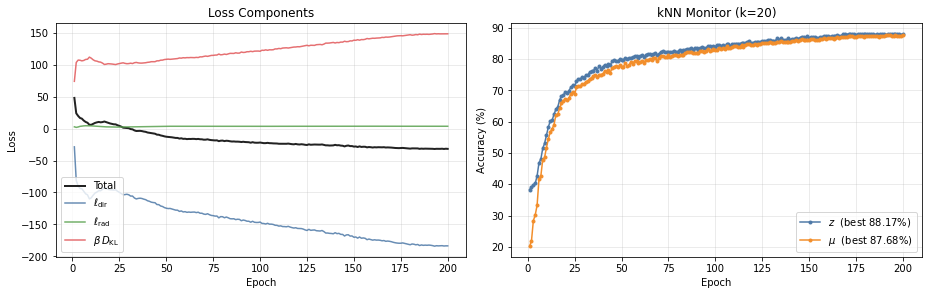

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
epochs_x = np.arange(1, len(history['loss']) + 1)

ax = axes[0]
ax.plot(epochs_x, history['loss'], label='Total', lw=2, color='#222222')
ax.plot(epochs_x, history['loss_dir'], label=r'$\ell_{\mathrm{dir}}$', alpha=0.85, color='#4E79A7')
ax.plot(epochs_x, history['loss_rad'], label=r'$\ell_{\mathrm{rad}}$', alpha=0.85, color='#59A14F')
ax.plot(epochs_x, history['loss_kld'], label=r'$\beta\,D_{\mathrm{KL}}$', alpha=0.85, color='#E15759')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Components')
ax.legend()
ax.grid(alpha=0.3)

mode_labels = {'z': r'$z$', 'mu': r'$\mu$', 'z_ema': r'$\tilde z$ (EMA)'}
mode_colors = {'z': '#4E79A7', 'mu': '#F28E2B', 'z_ema': '#59A14F'}

ax = axes[1]
for m in modes:
    series = [100 * a for a in history[f'knn_{m}']]
    ax.plot(
        epochs_x,
        series,
        'o-',
        markersize=3,
        label=f'{mode_labels[m]}  (best {max(series):.2f}%)',
        color=mode_colors[m],
    )

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'kNN Monitor (k={KNN_K})')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# # Save trained model and history (uncomment to enable).
# ckpt = {
#     'model_state_dict': model.state_dict(),
#     'config': {
#         'dataset': DATASET, 'epochs': EPOCHS,
#         'nu': NU, 'beta': BETA, 'center_cov': CENTER_COV,
#         'use_radial': USE_RADIAL,
#         'use_ema': USE_EMA, 'ema_base': EMA_BASE,
#         'bottleneck_ratio': BOTTLENECK_RATIO,
#     },
#     'history': history,
# }
# out_path = f'vje_{DATASET}_ep{EPOCHS}{"_ema" if USE_EMA else ""}.pt'
# torch.save(ckpt, out_path)
# print(f'Saved checkpoint to {out_path}')

## Citation

If you use this code, please cite:

```bibtex
@article{oji2026vje,
  title   = {Joint Embedding Variational Bayes},
  author  = {Amin Oji and Paul W. Fieguth},
  journal = {Transactions on Machine Learning Research},
  issn    = {2835-8856},
  year    = {2026},
  url     = {https://openreview.net/forum?id=4cbPJ5jLtr}
}
```

## References

- Grill, J.-B. et al. *Bootstrap Your Own Latent (BYOL): A New Approach to Self-Supervised Learning.* NeurIPS 2020.
- Chen, X. & He, K. *Exploring Simple Siamese Representation Learning (SimSiam).* CVPR 2021.